[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QuantLet/EMQA/blob/main/EMQA_collar_strategy/EMQA_collar_strategy.ipynb)

# EMQA_collar_strategy
Collar strategy for energy commodities: buy a protective put and sell a covered call to limit both downside risk and upside potential. EnergiaCorp zero-cost collar example.
**Output:** `deriv_collar_payoff.pdf`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    'savefig.facecolor': 'none',
    'savefig.transparent': True,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'figure.figsize': (12, 6),
})

COLORS = {
    'blue': '#1A3A6E', 'red': '#CD0000', 'green': '#2E7D32',
    'orange': '#E67E22', 'purple': '#8E44AD', 'gray': '#808080',
    'cyan': '#00BCD4', 'amber': '#B5853F'
}

def save_fig(fig, name):
    fig.savefig(name, bbox_inches='tight', transparent=True, dpi=300)
    print(f"Saved: {name}")
    if name.endswith('.pdf'):
        png_name = name[:-4] + '.png'
        fig.savefig(png_name, bbox_inches='tight', transparent=True, dpi=300)
        print(f"Saved: {png_name}")

In [2]:
# Collar Strategy Parameters — EnergiaCorp zero-cost collar
# A producer owns energy and wants to hedge price risk

S0 = 95   # Current energy price (EUR/MWh)
K_put = 80   # Put strike (floor price)
K_call = 110  # Call strike (ceiling price)
put_premium = 3.0   # Premium paid for protective put
call_premium = 3.0   # Premium received for selling call
net_premium = put_premium - call_premium  # Zero-cost collar: net = 0

print(f"Current spot price: €{S0}/MWh")
print(f"Put strike (floor): €{K_put}/MWh")
print(f"Call strike (cap): €{K_call}/MWh")
print(f"Put premium paid: €{put_premium}")
print(f"Call premium received: €{call_premium}")
print(f"Net premium cost: €{net_premium} (zero-cost collar)")

Current spot price: €95/MWh
Put strike (floor): €80/MWh
Call strike (cap): €110/MWh
Put premium paid: €3.0
Call premium received: €3.0
Net premium cost: €0.0 (zero-cost collar)


In [3]:
# Calculate payoffs across a range of spot prices at expiration
S_range = np.linspace(50, 140, 500)

# Individual position payoffs
# Long underlying (producer owns the commodity)
underlying_pnl = S_range - S0

# Long put payoff (protective put)
long_put_payoff = np.maximum(K_put - S_range, 0) - put_premium

# Short call payoff (covered call - sold)
short_call_payoff = -np.maximum(S_range - K_call, 0) + call_premium

# Combined collar payoff = Underlying + Long Put + Short Call
collar_payoff = underlying_pnl + long_put_payoff + short_call_payoff

# Unhedged position (just the underlying)
unhedged_payoff = underlying_pnl

Saved: deriv_collar_payoff.pdf


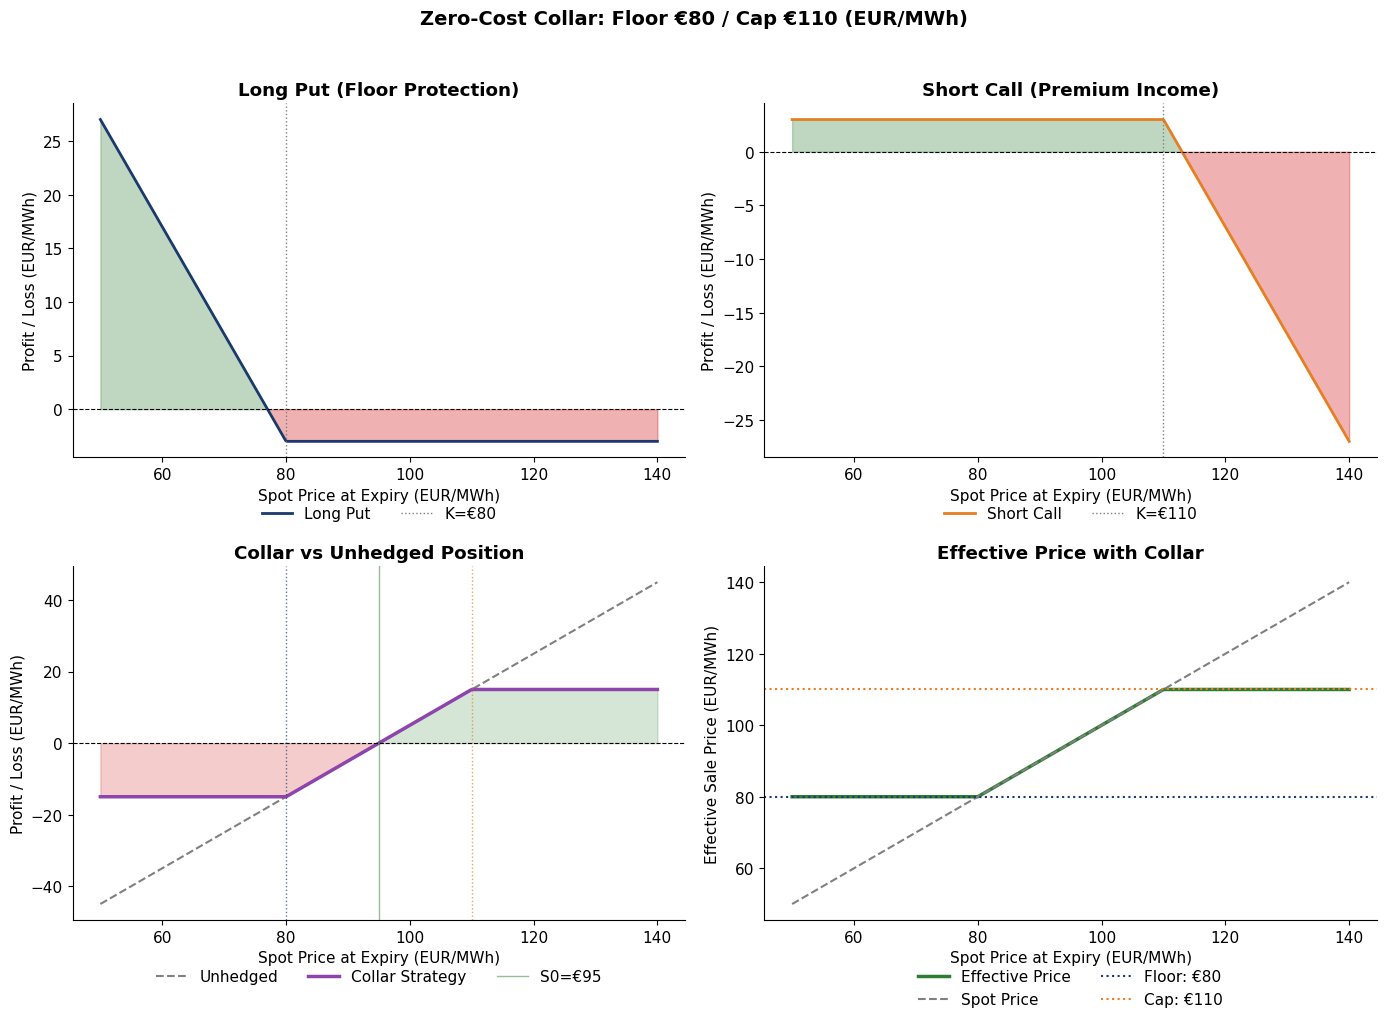

In [4]:
# Create 2x2 panel figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Long Put (Protective Put)
ax1 = axes[0, 0]
ax1.plot(S_range, long_put_payoff, color=COLORS['blue'], linewidth=2, label='Long Put')
ax1.fill_between(S_range, long_put_payoff, 0, where=(long_put_payoff > 0),
                 color=COLORS['green'], alpha=0.3)
ax1.fill_between(S_range, long_put_payoff, 0, where=(long_put_payoff < 0),
                 color=COLORS['red'], alpha=0.3)
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.axvline(K_put, color=COLORS['gray'], linestyle=':', linewidth=1, label=f'K=€{K_put}')
ax1.set_xlabel('Spot Price at Expiry (EUR/MWh)')
ax1.set_ylabel('Profit / Loss (EUR/MWh)')
ax1.set_title('Long Put (Floor Protection)', fontweight='bold')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False, ncol=2)

# Panel 2: Short Call (Covered Call)
ax2 = axes[0, 1]
ax2.plot(S_range, short_call_payoff, color=COLORS['orange'], linewidth=2, label='Short Call')
ax2.fill_between(S_range, short_call_payoff, 0, where=(short_call_payoff > 0),
                 color=COLORS['green'], alpha=0.3)
ax2.fill_between(S_range, short_call_payoff, 0, where=(short_call_payoff < 0),
                 color=COLORS['red'], alpha=0.3)
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.axvline(K_call, color=COLORS['gray'], linestyle=':', linewidth=1, label=f'K=€{K_call}')
ax2.set_xlabel('Spot Price at Expiry (EUR/MWh)')
ax2.set_ylabel('Profit / Loss (EUR/MWh)')
ax2.set_title('Short Call (Premium Income)', fontweight='bold')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False, ncol=2)

# Panel 3: Combined Collar Payoff vs Unhedged
ax3 = axes[1, 0]
ax3.plot(S_range, unhedged_payoff, color=COLORS['gray'], linewidth=1.5, 
         linestyle='--', label='Unhedged')
ax3.plot(S_range, collar_payoff, color=COLORS['purple'], linewidth=2.5, label='Collar Strategy')
ax3.fill_between(S_range, collar_payoff, 0, where=(collar_payoff > 0),
                 color=COLORS['green'], alpha=0.2)
ax3.fill_between(S_range, collar_payoff, 0, where=(collar_payoff < 0),
                 color=COLORS['red'], alpha=0.2)
ax3.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax3.axvline(K_put, color=COLORS['blue'], linestyle=':', linewidth=1, alpha=0.7)
ax3.axvline(K_call, color=COLORS['orange'], linestyle=':', linewidth=1, alpha=0.7)
ax3.axvline(S0, color=COLORS['green'], linestyle='-', linewidth=1, alpha=0.5, label=f'S0=€{S0}')
ax3.set_xlabel('Spot Price at Expiry (EUR/MWh)')
ax3.set_ylabel('Profit / Loss (EUR/MWh)')
ax3.set_title('Collar vs Unhedged Position', fontweight='bold')
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False, ncol=3)

# Panel 4: Effective Price Received
ax4 = axes[1, 1]
effective_price = S_range + np.maximum(K_put - S_range, 0) - np.maximum(S_range - K_call, 0) - net_premium
ax4.plot(S_range, effective_price, color=COLORS['green'], linewidth=2.5, label='Effective Price')
ax4.plot(S_range, S_range, color=COLORS['gray'], linewidth=1.5, linestyle='--', label='Spot Price')
ax4.axhline(K_put - net_premium, color=COLORS['blue'], linestyle=':', linewidth=1.5, 
            label=f'Floor: €{K_put - net_premium:.0f}')
ax4.axhline(K_call - net_premium, color=COLORS['orange'], linestyle=':', linewidth=1.5,
            label=f'Cap: €{K_call - net_premium:.0f}')
ax4.set_xlabel('Spot Price at Expiry (EUR/MWh)')
ax4.set_ylabel('Effective Sale Price (EUR/MWh)')
ax4.set_title('Effective Price with Collar', fontweight='bold')
ax4.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False, ncol=2)

fig.suptitle('Zero-Cost Collar: Floor €80 / Cap €110 (EUR/MWh)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'deriv_collar_payoff.pdf')
plt.show()

In [5]:
# Summary statistics
floor_price = K_put - net_premium
cap_price = K_call - net_premium

print("=" * 50)
print("COLLAR STRATEGY SUMMARY (EnergiaCorp)")
print("=" * 50)
print(f"Floor price (min sale price): €{floor_price:.0f}/MWh")
print(f"Cap price (max sale price): €{cap_price:.0f}/MWh")
print(f"Range protected: €{floor_price:.0f} – €{cap_price:.0f}")
print(f"Net premium cost: €{net_premium:.0f} (zero-cost collar)")
print("\nWhen to use:")
print("- Producer wants downside protection")
print("- Willing to give up some upside to reduce cost")
print("- Zero-cost collar: put premium = call premium")

COLLAR STRATEGY SUMMARY (EnergiaCorp)
Floor price (min sale price): €80/MWh
Cap price (max sale price): €110/MWh
Range protected: €80 – €110
Net premium cost: €0 (zero-cost collar)

When to use:
- Producer wants downside protection
- Willing to give up some upside to reduce cost
- Zero-cost collar: put premium = call premium
